In [6]:
import matplotlib.pyplot as plt
import numpy as np

print("Libraries loaded successfully!")

def nars_belief(positive, negative):
    """
    Calculates NARS belief truth value.

    positive = number of confirming observations
    negative = number of contradicting observations

    Returns:
        f = frequency  (how true the belief seems)
        c = confidence (how much evidence exists)
        k = total evidence count
    """
    k = positive + negative

    if k == 0:
        return 0.5, 0.0, 0

    f = positive / k
    c = k / (k + 1)

    return round(f, 3), round(c, 3), k


print("\n--- Testing the NARS formula ---\n")

# Test 1: one confirming observation
f, c, k = nars_belief(positive=1, negative=0)
print(f"After 1 confirm:        f={f}  c={c}  k={k}")

# Test 2: five confirming observations
f, c, k = nars_belief(positive=5, negative=0)
print(f"After 5 confirms:       f={f}  c={c}  k={k}")

# Test 3: five confirms and one contradiction
f, c, k = nars_belief(positive=5, negative=1)
print(f"5 confirms + 1 contra:  f={f}  c={c}  k={k}")

# Test 4: equal confirms and contradictions
f, c, k = nars_belief(positive=5, negative=5)
print(f"5 confirms + 5 contra:  f={f}  c={c}  k={k}")

print("\nFormula working correctly!")

Libraries loaded successfully!

--- Testing the NARS formula ---

After 1 confirm:        f=1.0  c=0.5  k=1
After 5 confirms:       f=1.0  c=0.833  k=5
5 confirms + 1 contra:  f=0.833  c=0.857  k=6
5 confirms + 5 contra:  f=0.5  c=0.909  k=10

Formula working correctly!


In [ ]:
print("=" * 55)
print("Belief: 'Birds can fly'")
print("=" * 55)

observations = [
    ("Sparrow flies",    True),
    ("Eagle soars",      True),
    ("Robin flies",      True),
    ("Pigeon takes off", True),
    ("Hawk circles",     True),
    ("Penguin walks",    False),
    ("Ostrich runs",     False),
    ("Swallow dives",    True),
    ("Kiwi hides",       False),
    ("Crane lifts off",  True),
]

stage1_results = []

pos = 0
neg = 0

print(f"\n{'Observation':<20} {'Type':<12} {'Pos':>4} {'Neg':>4} {'k':>4} {'f':>7} {'c':>7}")
print("-" * 60)

for obs, is_confirm in observations:
    if is_confirm:
        pos += 1
    else:
        neg += 1

    f, c, k = nars_belief(positive=pos, negative=neg)
    obs_type = "CONFIRMS" if is_confirm else "CONTRADICTS"

    print(f"{obs:<20} {obs_type:<12} {pos:>4} {neg:>4} {k:>4} {f:>7} {c:>7}")

    stage1_results.append({
        "observation" : obs,
        "type"        : obs_type,
        "positive"    : pos,
        "negative"    : neg,
        "k"           : k,
        "f"           : f,
        "c"           : c
    })

print("-" * 60)

# Final belief state
last = stage1_results[-1]
print(f"\nFinal belief state after {last['k']} observations:")
print(f"  Frequency (f)  = {last['f']}  → belief seems {round(last['f']*100)}% true")
print(f"  Confidence (c) = {last['c']}  → strong evidence base")

if last['f'] > 0.7:
    verdict = "HOLDS — belief is stable despite contradictions"
elif last['f'] > 0.5:
    verdict = "LEANS TRUE — more confirms than contradictions"
elif last['f'] == 0.5:
    verdict = "UNCERTAIN — equal evidence on both sides"
else:
    verdict = "REVERSED — contradictions outweigh confirms"

print(f"  Verdict        : {verdict}")

Belief: 'Birds can fly'

Observation          Type          Pos  Neg    k       f       c
------------------------------------------------------------
Sparrow flies        CONFIRMS        1    0    1     1.0     0.5
Eagle soars          CONFIRMS        2    0    2     1.0   0.667
Robin flies          CONFIRMS        3    0    3     1.0    0.75
Pigeon takes off     CONFIRMS        4    0    4     1.0     0.8
Hawk circles         CONFIRMS        5    0    5     1.0   0.833
Penguin walks        CONTRADICTS     5    1    6   0.833   0.857
Ostrich runs         CONTRADICTS     5    2    7   0.714   0.875
Swallow dives        CONFIRMS        6    2    8    0.75   0.889
Kiwi hides           CONTRADICTS     6    3    9   0.667     0.9
Crane lifts off      CONFIRMS        7    3   10     0.7   0.909
------------------------------------------------------------

Final belief state after 10 observations:
  Frequency (f)  = 0.7  → belief seems 70% true
  Confidence (c) = 0.909  → strong evidence bas

In [ ]:
print("=" * 55)
print("=" * 55)

print("""
What we are testing:
Can NARS connect separate facts and reach a conclusion
it was never directly told?

Facts we give it:
  Fact 1: Cats are mammals
  Fact 2: Mammals are warm-blooded
  Fact 3: Warm-blooded animals need food regularly

Question we ask:
  Do cats need food regularly?
  (We NEVER directly told it this)
""")

print("-" * 55)
print("FEEDING THE THREE FACTS INTO THE SYSTEM")
print("-" * 55)

fact1_f, fact1_c, fact1_k = nars_belief(positive=9, negative=1)
print(f"Fact 1 — Cats are mammals")
print(f"         f={fact1_f}  c={fact1_c}  (strong, direct fact)\n")

fact2_f, fact2_c, fact2_k = nars_belief(positive=9, negative=1)
print(f"Fact 2 — Mammals are warm-blooded")
print(f"         f={fact2_f}  c={fact2_c}  (strong, direct fact)\n")

fact3_f, fact3_c, fact3_k = nars_belief(positive=9, negative=1)
print(f"Fact 3 — Warm-blooded animals need food regularly")
print(f"         f={fact3_f}  c={fact3_c}  (strong, direct fact)\n")


print("-" * 55)
print("INFERENCE — CHAINING THE FACTS TOGETHER")
print("-" * 55)

f_inferred = round(fact1_f * fact2_f * fact3_f, 3)
c_inferred = round(fact1_c * fact2_c * fact3_c, 3)

print(f"""
Inference chain:
  Cats → mammals         (f={fact1_f}, c={fact1_c})
       ↓
  Mammals → warm-blooded (f={fact2_f}, c={fact2_c})
       ↓
  Warm-blooded → need food (f={fact3_f}, c={fact3_c})
       ↓
  INFERRED: Cats need food regularly
""")

print(f"Inferred truth value:")
print(f"  f = {fact1_f} × {fact2_f} × {fact3_f} = {f_inferred}")
print(f"  c = {fact1_c} × {fact2_c} × {fact3_c} = {c_inferred}")

print(f"""
Result:
  f = {f_inferred}  → the system believes this is {round(f_inferred*100)}% likely true
  c = {c_inferred}  → moderate confidence from chained evidence

This conclusion was NEVER directly stated.
NARS derived it entirely from the three input facts.
This is called DEDUCTIVE INFERENCE.
""")


print("-" * 55)
print("DIRECT FACT vs INFERRED CONCLUSION")
print("-" * 55)

print(f"  Direct fact   'Cats are mammals':         f={fact1_f}  c={fact1_c}")
print(f"  Inferred fact 'Cats need food regularly': f={f_inferred}  c={c_inferred}")
print(f"""
Notice:
  The inferred belief has LOWER confidence than the
  direct facts — because uncertainty multiplies as
  you chain facts together. This is exactly what
  we expect from a rational reasoning system.
""")



stage1b_result = {
    "fact1_f": fact1_f, "fact1_c": fact1_c,
    "fact2_f": fact2_f, "fact2_c": fact2_c,
    "fact3_f": fact3_f, "fact3_c": fact3_c,
    "inferred_f": f_inferred,
    "inferred_c": c_inferred
}


What we are testing:
Can NARS connect separate facts and reach a conclusion
it was never directly told?

Facts we give it:
  Fact 1: Cats are mammals
  Fact 2: Mammals are warm-blooded
  Fact 3: Warm-blooded animals need food regularly

Question we ask:
  Do cats need food regularly?
  (We NEVER directly told it this)

-------------------------------------------------------
FEEDING THE THREE FACTS INTO THE SYSTEM
-------------------------------------------------------
Fact 1 — Cats are mammals
         f=0.9  c=0.909  (strong, direct fact)

Fact 2 — Mammals are warm-blooded
         f=0.9  c=0.909  (strong, direct fact)

Fact 3 — Warm-blooded animals need food regularly
         f=0.9  c=0.909  (strong, direct fact)

-------------------------------------------------------
INFERENCE — CHAINING THE FACTS TOGETHER
-------------------------------------------------------

Inference chain:
  Cats → mammals         (f=0.9, c=0.909)
       ↓
  Mammals → warm-blooded (f=0.9, c=0.909)
       ↓


In [ ]:
print("=" * 55)
print("STAGE 2 — REINFORCEMENT EXPERIMENT")
print("Belief: 'Birds can fly'")
print("=" * 55)

print("""
What we are testing:
We feed the system confirming observations in batches
of 5, 10, and 20 and measure how quickly the belief
stabilises and when confidence stops growing.
""")


print(f"\n{'Confirms':>9} {'f':>8} {'c':>8} {'Change in c':>12}  Status")
print("-" * 60)

stage2_results = []
prev_c = 0.0

for i in range(1, 21):
    f, c, k = nars_belief(positive=i, negative=0)
    change = round(c - prev_c, 4)


    if i == 5:
        status = "<-- Batch 1 (5 confirms)"
    elif i == 10:
        status = "<-- Batch 2 (10 confirms)"
    elif i == 20:
        status = "<-- Batch 3 (20 confirms)"
    elif change < 0.01 and i > 5:
        status = "< diminishing returns"
    else:
        status = ""

    print(f"{i:>9} {f:>8} {c:>8} {change:>12}  {status}")

    stage2_results.append({
        "confirms" : i,
        "f"        : f,
        "c"        : c,
        "change_c" : change
    })

    prev_c = c


print("\n" + "-" * 55)
print("FINDING THE CONVERGENCE POINT")
print("-" * 55)

convergence_point = None
for r in stage2_results:
    if r["change_c"] < 0.01 and r["confirms"] > 3:
        convergence_point = r["confirms"]
        break

print(f"""
Convergence point: observation {convergence_point}

This means after {convergence_point} confirming observations,
each new observation adds less than 0.01 to confidence.
The belief has effectively stabilised.

Key insight:
  Early confirms matter a LOT — confidence jumps fast
  Later confirms matter less and less
  This is the k / (k+1) diminishing returns curve
""")


print("-" * 55)
print("BATCH SUMMARY")
print("-" * 55)

batches = [5, 10, 20]
for b in batches:
    r = stage2_results[b - 1]
    print(f"After {b:>2} confirms:  f={r['f']}  c={r['c']}")

print(f"""
Notice:
  f stays at 1.0 throughout — no contradictions yet
  c grows fast early, then slows down
  By observation 10 the belief is already very stable
  Going from 10 to 20 only adds about 0.05 to confidence
""")



STAGE 2 — REINFORCEMENT EXPERIMENT
Belief: 'Birds can fly'

What we are testing:
We feed the system confirming observations in batches
of 5, 10, and 20 and measure how quickly the belief
stabilises and when confidence stops growing.


 Confirms        f        c  Change in c  Status
------------------------------------------------------------
        1      1.0      0.5          0.5  
        2      1.0    0.667        0.167  
        3      1.0     0.75        0.083  
        4      1.0      0.8         0.05  
        5      1.0    0.833        0.033  <-- Batch 1 (5 confirms)
        6      1.0    0.857        0.024  
        7      1.0    0.875        0.018  
        8      1.0    0.889        0.014  
        9      1.0      0.9        0.011  
       10      1.0    0.909        0.009  <-- Batch 2 (10 confirms)
       11      1.0    0.917        0.008  < diminishing returns
       12      1.0    0.923        0.006  < diminishing returns
       13      1.0    0.929        0.006  < dimi

In [ ]:
print("=" * 55)
print("STAGE 3 — CONTRADICTION STRESS TEST")
print("Belief: 'Birds can fly'")
print("=" * 55)

print("""
What we are testing:
We first build a stable belief with 10 confirming
observations. Then we inject contradictions at three
levels — light, moderate, and heavy — and measure
how much the belief shifts each time.
""")


base_confirms = 10
f_base, c_base, k_base = nars_belief(positive=base_confirms, negative=0)

print("-" * 55)
print("STARTING BELIEF (after 10 confirming observations)")
print("-" * 55)
print(f"  f = {f_base}  (fully believes birds can fly)")
print(f"  c = {c_base}  (strong evidence base)")
print(f"  k = {k_base}  (total observations)")


conditions = [
    ("LIGHT",    2,  "2 contradictions"),
    ("MODERATE", 5,  "5 contradictions"),
    ("HEAVY",    10, "10 contradictions — equal to confirms"),
]

stage3_results = []

print(f"\n{'Condition':<10} {'Contradictions':>15} {'f before':>10} {'f after':>10} {'f drop':>8} {'c after':>10}  Verdict")
print("-" * 80)

for level, neg, desc in conditions:
    f_after, c_after, k_after = nars_belief(
        positive=base_confirms,
        negative=neg)

    f_drop = round(f_base - f_after, 3)

    if f_after > 0.7:
        verdict = "Belief holds strong"
    elif f_after > 0.6:
        verdict = "Belief holds above threshold"
    elif f_after > 0.5:
        verdict = "Belief weakening"
    elif f_after == 0.5:
        verdict = "Genuinely uncertain"
    else:
        verdict = "Belief reversed"

    print(f"{level:<10} {desc:>15} {f_base:>10} {f_after:>10} {f_drop:>8}  {c_after:>10}  {verdict}")

    stage3_results.append({
        "level"       : level,
        "contradictions": neg,
        "f_before"    : f_base,
        "f_after"     : f_after,
        "f_drop"      : f_drop,
        "c_after"     : c_after,
        "verdict"     : verdict
    })


print("\n")
print("-" * 55)
print("STEP BY STEP — WATCHING EACH CONTRADICTION ARRIVE")
print("-" * 55)

print(f"\n{'Step':<6} {'What happened':<30} {'f':>7} {'c':>7}  Note")
print("-" * 65)

pos = base_confirms
neg = 0

# first show the stable starting point
f, c, k = nars_belief(pos, neg)
print(f"{'Start':<6} {'10 confirms done':<30} {f:>7} {c:>7}  Belief fully stable")

# now add contradictions one by one up to 10
for i in range(1, 11):
    neg += 1
    f, c, k = nars_belief(pos, neg)

    if i == 2:
        note = "<-- Light threshold"
    elif i == 5:
        note = "<-- Moderate threshold"
    elif i == 10:
        note = "<-- Heavy threshold (equal)"
    elif f < 0.6:
        note = "!! Below stable threshold"
    else:
        note = ""

    print(f"{i:<6} {f'Contradiction {i} arrives':<30} {f:>7} {c:>7}  {note}")






STAGE 3 — CONTRADICTION STRESS TEST
Belief: 'Birds can fly'

What we are testing:
We first build a stable belief with 10 confirming
observations. Then we inject contradictions at three
levels — light, moderate, and heavy — and measure
how much the belief shifts each time.

-------------------------------------------------------
STARTING BELIEF (after 10 confirming observations)
-------------------------------------------------------
  f = 1.0  (fully believes birds can fly)
  c = 0.909  (strong evidence base)
  k = 10  (total observations)

Condition   Contradictions   f before    f after   f drop    c after  Verdict
--------------------------------------------------------------------------------
LIGHT      2 contradictions        1.0      0.833    0.167       0.923  Belief holds strong
MODERATE   5 contradictions        1.0      0.667    0.333       0.938  Belief holds above threshold
HEAVY      10 contradictions — equal to confirms        1.0        0.5      0.5       0.952  Genuinel

Generating all 5 charts...


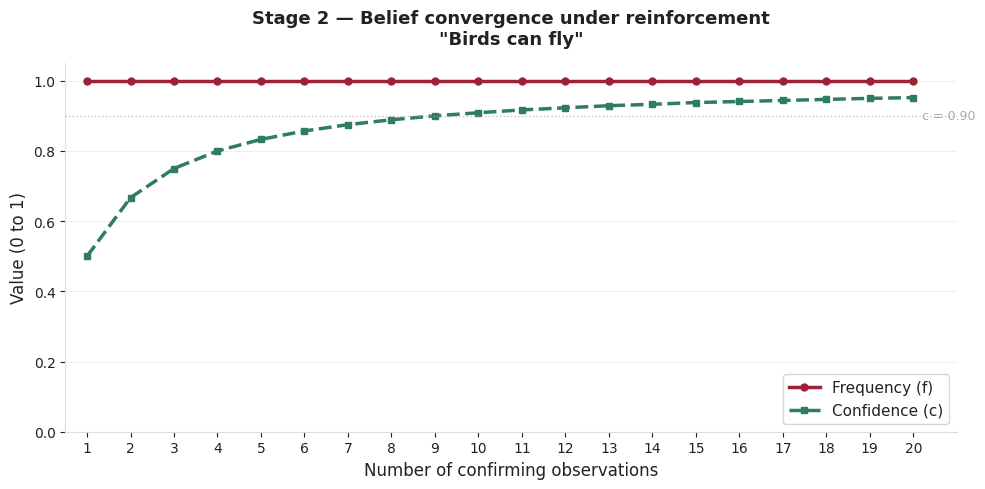

Chart 1 done — chart1_convergence.png


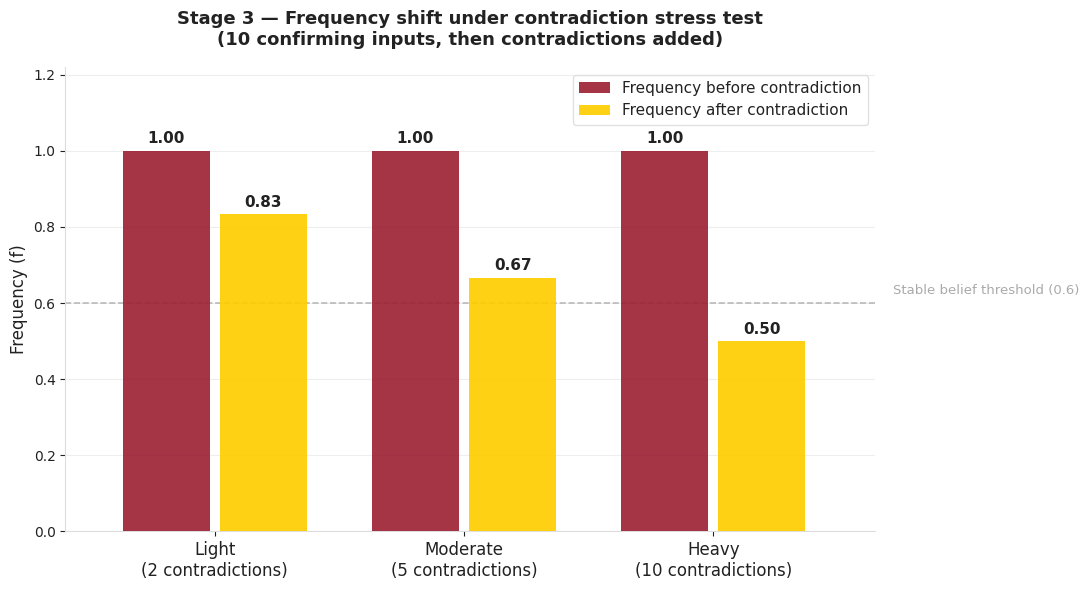

Chart 2 done — chart2_contradiction.png


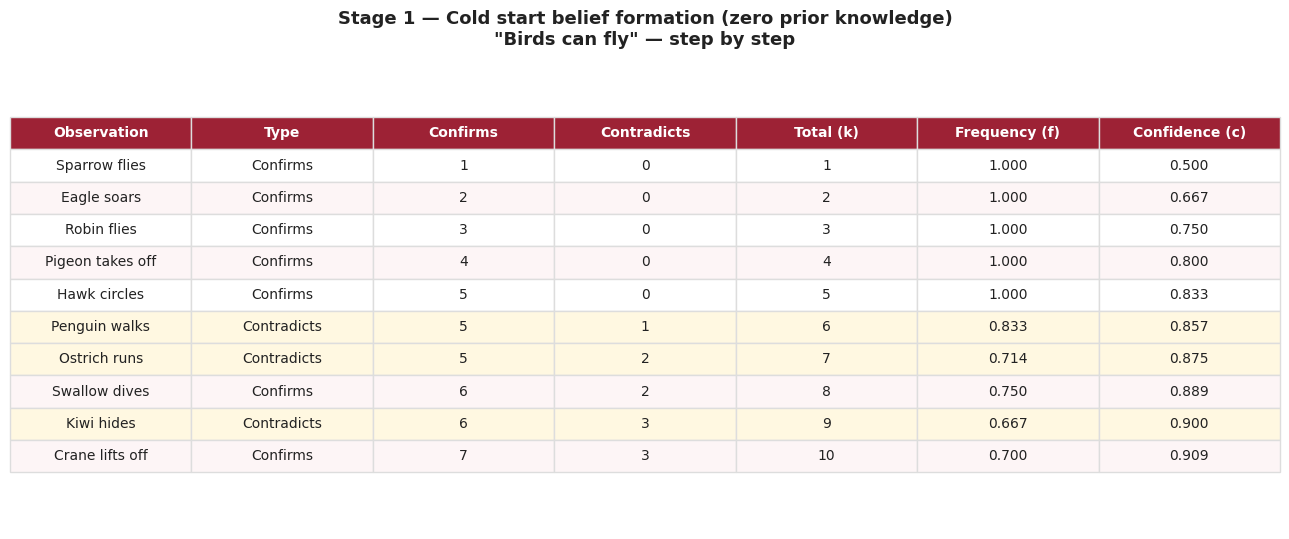

Chart 3 done — chart3_table.png


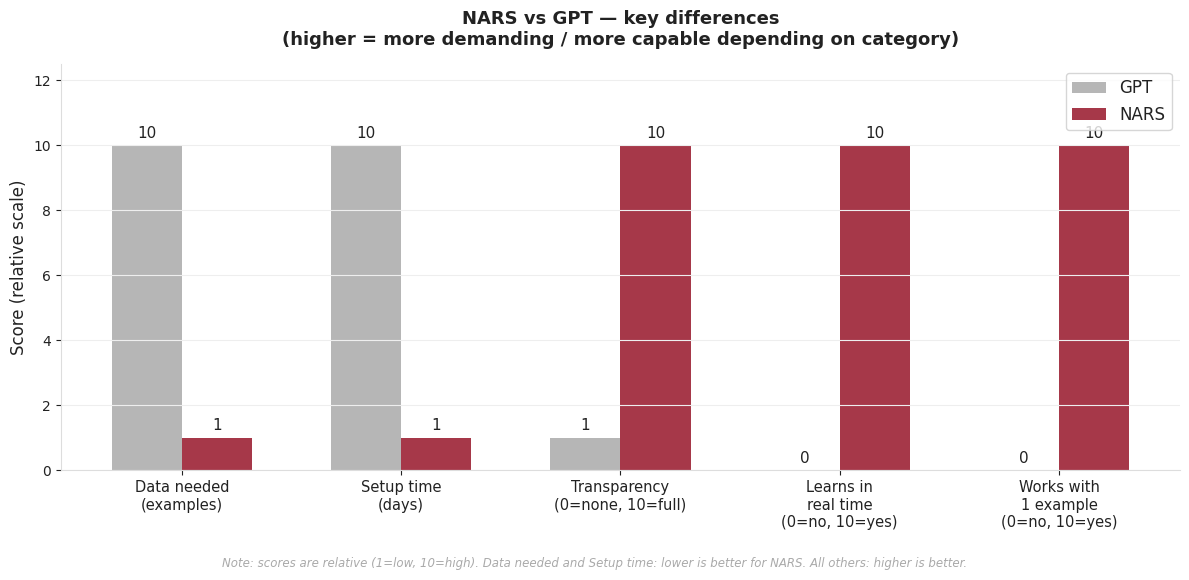

Chart 4 done — chart4_comparison.png


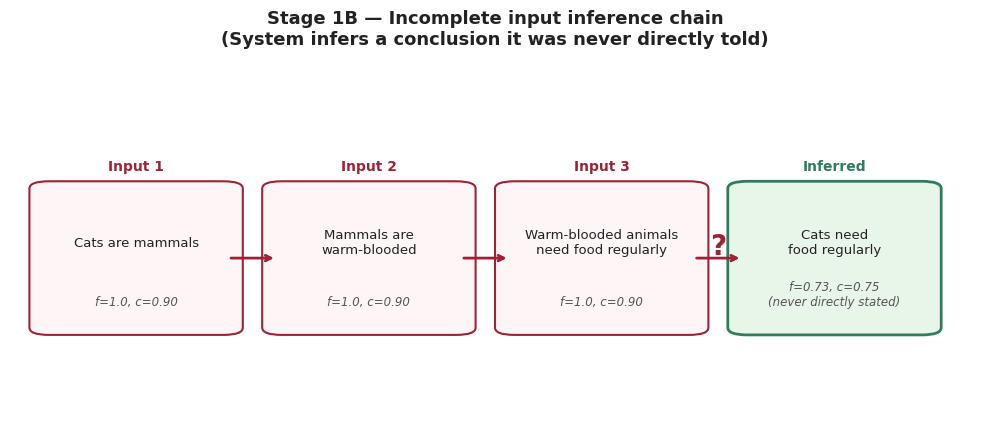

Chart 5 done — chart5_inference.png


In [10]:

CHERRY = "#9D2235"
WHITE  = "#FFFFFF"
DARK   = "#222222"
GRAY   = "#AAAAAA"
GOLD   = "#FFCD00"
TEAL   = "#2E7D5E"

plt.rcParams.update({
    'font.family'        : 'DejaVu Sans',
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'figure.facecolor'   : WHITE,
    'axes.facecolor'     : WHITE,
    'text.color'         : DARK,
    'axes.labelcolor'    : DARK,
    'xtick.color'        : DARK,
    'ytick.color'        : DARK,
})

print("Generating all 5 charts...")


# CHART 1 — Stage 2 Belief Convergence


steps     = list(range(1, 21))
freq_vals = []
conf_vals = []

for i in steps:
    f, c, _ = nars_belief(positive=i, negative=0)
    freq_vals.append(f)
    conf_vals.append(c)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(steps, freq_vals,
        color=CHERRY, linewidth=2.5,
        marker='o', markersize=5,
        label='Frequency (f)')

ax.plot(steps, conf_vals,
        color=TEAL, linewidth=2.5,
        marker='s', markersize=5,
        linestyle='--',
        label='Confidence (c)')

ax.axhline(y=0.9, color=GRAY, linewidth=1,
           linestyle=':', alpha=0.7)
ax.text(20.2, 0.9, 'c = 0.90',
        fontsize=9, color=GRAY, va='center')

ax.set_xlabel('Number of confirming observations', fontsize=12)
ax.set_ylabel('Value (0 to 1)', fontsize=12)
ax.set_title(
    'Stage 2 — Belief convergence under reinforcement\n"Birds can fly"',
    fontsize=13, fontweight='bold', color=DARK, pad=14)
ax.set_ylim(0, 1.05)
ax.set_xlim(0.5, 21)
ax.set_xticks(steps)
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='y', color='#EEEEEE', linewidth=0.8)

for spine in ax.spines.values():
    spine.set_color('#DDDDDD')

plt.tight_layout()
plt.savefig('chart1_convergence.png', dpi=180,
            bbox_inches='tight', facecolor=WHITE)
plt.show()
print("Chart 1 done — chart1_convergence.png")


# CHART 2 — Stage 3 Contradiction Stress Test


conditions = [
    ('Light\n(2 contradictions)',     10, 2),
    ('Moderate\n(5 contradictions)',  10, 5),
    ('Heavy\n(10 contradictions)',    10, 10),
]

before_freqs = []
after_freqs  = []
labels       = []

for label, pos, neg in conditions:
    bf, _, _ = nars_belief(positive=pos, negative=0)
    af, _, _ = nars_belief(positive=pos, negative=neg)
    before_freqs.append(bf)
    after_freqs.append(af)
    labels.append(label)

x     = np.arange(len(labels))
width = 0.35
gap   = 0.04

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(x - width/2 - gap/2, before_freqs, width,
               label='Frequency before contradiction',
               color=CHERRY, alpha=0.92, zorder=3)

bars2 = ax.bar(x + width/2 + gap/2, after_freqs, width,
               label='Frequency after contradiction',
               color=GOLD, alpha=0.92, zorder=3)

ax.axhline(y=0.6, color=GRAY, linewidth=1.2,
           linestyle='--', alpha=0.8, zorder=2)
ax.text(2.72, 0.615, 'Stable belief threshold (0.6)',
        fontsize=9.5, color=GRAY, va='bottom')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.012,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold', color=DARK)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.012,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold', color=DARK)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Frequency (f)', fontsize=12)
ax.set_ylim(0, 1.22)
ax.set_xlim(-0.6, 2.65)
ax.set_title(
    'Stage 3 — Frequency shift under contradiction stress test\n'
    '(10 confirming inputs, then contradictions added)',
    fontsize=13, fontweight='bold', color=DARK, pad=16)
ax.legend(fontsize=11, loc='upper right',
          framealpha=0.9, edgecolor='#DDDDDD')
ax.grid(axis='y', color='#EEEEEE', linewidth=0.8, zorder=0)

for spine in ax.spines.values():
    spine.set_color('#DDDDDD')

plt.tight_layout()
plt.savefig('chart2_contradiction.png', dpi=180,
            bbox_inches='tight', facecolor=WHITE)
plt.show()
print("Chart 2 done — chart2_contradiction.png")


# CHART 3 — Stage 1 Cold Start Table


observations = [
    ("Sparrow flies",    True),
    ("Eagle soars",      True),
    ("Robin flies",      True),
    ("Pigeon takes off", True),
    ("Hawk circles",     True),
    ("Penguin walks",    False),
    ("Ostrich runs",     False),
    ("Swallow dives",    True),
    ("Kiwi hides",       False),
    ("Crane lifts off",  True),
]

table_data = []
pos = 0
neg = 0

for obs, is_confirm in observations:
    if is_confirm:
        pos += 1
    else:
        neg += 1
    f, c, k = nars_belief(positive=pos, negative=neg)
    table_data.append([obs,
                       "Confirms" if is_confirm else "Contradicts",
                       pos, neg, k,
                       f"{f:.3f}", f"{c:.3f}"])

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.axis('off')

columns = ["Observation", "Type", "Confirms",
           "Contradicts", "Total (k)",
           "Frequency (f)", "Confidence (c)"]

table = ax.table(
    cellText=table_data,
    colLabels=columns,
    loc='center',
    cellLoc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.75)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#DDDDDD')
    if row == 0:
        cell.set_facecolor(CHERRY)
        cell.set_text_props(color=WHITE, fontweight='bold')
    elif table_data[row - 1][1] == "Contradicts":
        cell.set_facecolor("#FFF8E1")
    elif row % 2 == 0:
        cell.set_facecolor("#FDF5F6")
    else:
        cell.set_facecolor(WHITE)

ax.set_title(
    'Stage 1 — Cold start belief formation (zero prior knowledge)\n'
    '"Birds can fly" — step by step',
    fontsize=13, fontweight='bold', color=DARK,
    pad=18, y=0.98)

plt.tight_layout()
plt.savefig('chart3_table.png', dpi=180,
            bbox_inches='tight', facecolor=WHITE)
plt.show()
print("Chart 3 done — chart3_table.png")


# CHART 4 — NARS vs GPT Comparison


categories = [
    'Data needed\n(examples)',
    'Setup time\n(days)',
    'Transparency\n(0=none, 10=full)',
    'Learns in\nreal time\n(0=no, 10=yes)',
    'Works with\n1 example\n(0=no, 10=yes)'
]

gpt_scores  = [10, 10, 1,  0,  0]
nars_scores = [1,  1,  10, 10, 10]

x     = np.arange(len(categories))
width = 0.32

fig, ax = plt.subplots(figsize=(12, 5.5))

b1 = ax.bar(x - width/2, gpt_scores,
            width, label='GPT',
            color=GRAY, alpha=0.85)

b2 = ax.bar(x + width/2, nars_scores,
            width, label='NARS',
            color=CHERRY, alpha=0.9)

for bar in b1:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.15,
            str(int(bar.get_height())),
            ha='center', va='bottom',
            fontsize=11, color=DARK)

for bar in b2:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.15,
            str(int(bar.get_height())),
            ha='center', va='bottom',
            fontsize=11, color=DARK)

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10.5)
ax.set_ylim(0, 12.5)
ax.set_ylabel('Score (relative scale)', fontsize=12)
ax.set_title(
    'NARS vs GPT — key differences\n'
    '(higher = more demanding / more capable depending on category)',
    fontsize=13, fontweight='bold', color=DARK, pad=14)
ax.legend(fontsize=12)
ax.grid(axis='y', color='#EEEEEE', linewidth=0.8)

fig.text(
    0.5, -0.04,
    'Note: scores are relative (1=low, 10=high). '
    'Data needed and Setup time: lower is better for NARS. '
    'All others: higher is better.',
    ha='center', fontsize=8.5, color=GRAY, style='italic')

for spine in ax.spines.values():
    spine.set_color('#DDDDDD')

plt.tight_layout()
plt.savefig('chart4_comparison.png', dpi=180,
            bbox_inches='tight', facecolor=WHITE)
plt.show()
print("Chart 4 done — chart4_comparison.png")


# CHART 5 — Stage 1B Inference Chain


import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.axis('off')

chain = [
    ("Input 1", "Cats are mammals",
     "f=1.0, c=0.90", CHERRY),
    ("Input 2", "Mammals are\nwarm-blooded",
     "f=1.0, c=0.90", CHERRY),
    ("Input 3", "Warm-blooded animals\nneed food regularly",
     "f=1.0, c=0.90", CHERRY),
    ("Inferred", "Cats need\nfood regularly",
     "f=0.73, c=0.75\n(never directly stated)", TEAL),
]

box_w   = 0.18
box_h   = 0.38
gap     = 0.06
start_x = 0.04

for i, (label, fact, tv, color) in enumerate(chain):
    x_pos = start_x + i * (box_w + gap)
    y_pos = 0.28
    face  = "#E8F5E9" if i == 3 else "#FDF5F6"
    lw    = 2.0       if i == 3 else 1.5

    fancy = mpatches.FancyBboxPatch(
        (x_pos, y_pos), box_w, box_h,
        boxstyle="round,pad=0.02",
        linewidth=lw,
        edgecolor=color,
        facecolor=face,
        transform=ax.transAxes)
    ax.add_patch(fancy)

    ax.text(x_pos + box_w / 2,
            y_pos + box_h + 0.04,
            label,
            ha='center', va='bottom',
            fontsize=10, fontweight='bold',
            color=color,
            transform=ax.transAxes)

    ax.text(x_pos + box_w / 2,
            y_pos + box_h / 2 + 0.04,
            fact,
            ha='center', va='center',
            fontsize=9.5, color=DARK,
            transform=ax.transAxes)

    ax.text(x_pos + box_w / 2,
            y_pos + 0.05,
            tv,
            ha='center', va='bottom',
            fontsize=8.5, color="#555555",
            style='italic',
            transform=ax.transAxes)

    if i < 3:
        ax.annotate("",
            xy=(x_pos + box_w + gap - 0.005,
                y_pos + box_h / 2),
            xytext=(x_pos + box_w + 0.005,
                    y_pos + box_h / 2),
            xycoords='axes fraction',
            textcoords='axes fraction',
            arrowprops=dict(
                arrowstyle='->',
                color=CHERRY, lw=2.0))

    if i == 2:
        ax.text(start_x + 3 * (box_w + gap) - gap / 2,
                y_pos + box_h / 2 + 0.03,
                "?",
                ha='center', va='center',
                fontsize=20, color=CHERRY,
                fontweight='bold',
                transform=ax.transAxes)

ax.set_title(
    'Stage 1B — Incomplete input inference chain\n'
    '(System infers a conclusion it was never directly told)',
    fontsize=13, fontweight='bold', color=DARK, pad=14)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('chart5_inference.png', dpi=180,
            bbox_inches='tight', facecolor=WHITE)
plt.show()
print("Chart 5 done — chart5_inference.png")
